# Profiling Analysis — Image Mosaic Generator

Parts 2.1 and 2.2

## Setup

In [25]:
import os, sys
from pathlib import Path
LAB5_DIR = Path.home() / 'Desktop' / 'LAB5'
os.chdir(LAB5_DIR)
if str(LAB5_DIR) not in sys.path:
    sys.path.insert(0, str(LAB5_DIR))
print('Working directory:', os.getcwd())

Working directory: /Users/deep/Desktop/LAB5


In [26]:
import numpy as np
import cv2
import time
import cProfile
import pstats
import io
import matplotlib.pyplot as plt
print('Imports OK')

Imports OK


## 1. Load Tiles and Create Test Images

In [27]:
from mosaic_generator.tile_manager import TileManager

tm = TileManager('tiles/', tile_px=32)
n_tiles = tm.load_tiles()
tile_images     = tm.get_all_tiles()    # (N, 32, 32, 3)
tile_avg_colors = tm.get_avg_colors()   # (N, 3)
print(f'Loaded {n_tiles} tiles')

Loaded 87 tiles


In [28]:
# Test images created in memory — no files needed
rng = np.random.default_rng(42)
img_256  = rng.integers(0, 256, (256,  256,  3), dtype=np.uint8)
img_512  = rng.integers(0, 256, (512,  512,  3), dtype=np.uint8)
img_1024 = rng.integers(0, 256, (1024, 1024, 3), dtype=np.uint8)
print(f'img_256:  {img_256.shape}')
print(f'img_512:  {img_512.shape}')
print(f'img_1024: {img_1024.shape}')

img_256:  (256, 256, 3)
img_512:  (512, 512, 3)
img_1024: (1024, 1024, 3)


## 2. Naive Baseline

In [29]:
def naive_generate_mosaic(image, grid_cells=32, tile_px=32):
    canvas_size = grid_cells * tile_px
    img_resized = cv2.resize(image, (canvas_size, canvas_size), interpolation=cv2.INTER_AREA)
    output = np.zeros((canvas_size, canvas_size, 3), dtype=np.uint8)
    for row in range(grid_cells):
        for col in range(grid_cells):
            y0, y1 = row * tile_px, (row + 1) * tile_px
            x0, x1 = col * tile_px, (col + 1) * tile_px
            cell = img_resized[y0:y1, x0:x1]
            cell_avg = cell.reshape(-1, 3).mean(axis=0)
            best_idx, best_dist = 0, float('inf')
            for t_idx in range(len(tile_avg_colors)):
                diff = cell_avg - tile_avg_colors[t_idx]
                dist = float(np.dot(diff, diff))
                if dist < best_dist:
                    best_dist, best_idx = dist, t_idx
            output[y0:y1, x0:x1] = tile_images[best_idx]
    return output

out = naive_generate_mosaic(img_256, grid_cells=8, tile_px=32)
print(f'Sanity check passed: {out.shape}')

Sanity check passed: (256, 256, 3)


## 3. Baseline Timing

In [30]:
configs = [
    (img_256,  '256x256',   16),
    (img_256,  '256x256',   32),
    (img_512,  '512x512',   16),
    (img_512,  '512x512',   32),
    (img_1024, '1024x1024', 32),
    (img_1024, '1024x1024', 64),
]

baseline_times = {}
print(f"{'Image':<12} {'Grid':<8} {'Time (s)'}")
print('-' * 34)
for img, name, grid_cells in configs:
    t0 = time.perf_counter()
    _ = naive_generate_mosaic(img, grid_cells=grid_cells, tile_px=32)
    elapsed = time.perf_counter() - t0
    baseline_times[(name, grid_cells)] = elapsed
    print(f"{name:<12} {grid_cells}x{grid_cells:<4} {elapsed:.4f}s")

Image        Grid     Time (s)
----------------------------------
256x256      16x16   0.0335s
256x256      32x32   0.1280s
512x512      16x16   0.0328s
512x512      32x32   0.1271s
1024x1024    32x32   0.1263s
1024x1024    64x64   0.4983s


## 4. cProfile Analysis

In [31]:
pr = cProfile.Profile()
pr.enable()
_ = naive_generate_mosaic(img_512, grid_cells=32, tile_px=32)
pr.disable()

stream = io.StringIO()
pstats.Stats(pr, stream=stream).sort_stats('cumulative').print_stats(20)
print(stream.getvalue())

         111662 function calls in 0.137 seconds

   Ordered by: cumulative time
   List reduced from 36 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.137    0.068 /Users/deep/Library/Python/3.9/lib/python/site-packages/IPython/core/interactiveshell.py:3514(run_code)
        2    0.000    0.000    0.137    0.068 {built-in method builtins.exec}
        1    0.000    0.000    0.137    0.137 /var/folders/_v/561gl0fx72bdpw94bwncc00w0000gn/T/ipykernel_53121/2681658073.py:3(<module>)
        1    0.111    0.111    0.137    0.137 /var/folders/_v/561gl0fx72bdpw94bwncc00w0000gn/T/ipykernel_53121/1066731269.py:1(naive_generate_mosaic)
     1024    0.000    0.000    0.019    0.000 {method 'mean' of 'numpy.ndarray' objects}
     1024    0.003    0.000    0.019    0.000 /Users/deep/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:110(_mean)
     1024    0.012    0.000    0.012    0.000 {metho

## 5. line_profiler Analysis

In [32]:
from line_profiler import LineProfiler
lp = LineProfiler()
lp.add_function(naive_generate_mosaic)
lp(naive_generate_mosaic)(img_512, grid_cells=32, tile_px=32)
lp.print_stats()

Timer unit: 1e-09 s

Total time: 0.176544 s
File: /var/folders/_v/561gl0fx72bdpw94bwncc00w0000gn/T/ipykernel_53121/1066731269.py
Function: naive_generate_mosaic at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def naive_generate_mosaic(image, grid_cells=32, tile_px=32):
     2         1       1000.0   1000.0      0.0      canvas_size = grid_cells * tile_px
     3         1     243000.0 243000.0      0.1      img_resized = cv2.resize(image, (canvas_size, canvas_size), interpolation=cv2.INTER_AREA)
     4         1      37000.0  37000.0      0.0      output = np.zeros((canvas_size, canvas_size, 3), dtype=np.uint8)
     5        33       4000.0    121.2      0.0      for row in range(grid_cells):
     6      1056      87000.0     82.4      0.0          for col in range(grid_cells):
     7      1024     182000.0    177.7      0.1              y0, y1 = row * tile_px, (row + 1) * tile_px
     8      1024     160000.0  

## 6. Bottlenecks

**Bottleneck 1 — Nested grid loops**: `for row / for col` — 1024 Python iterations for 32x32 grid.  
**Fix**: NumPy reshape to extract all cells at once.

**Bottleneck 2 — Per-cell mean one at a time**: `cell.reshape(-1,3).mean()` called 1024x inside loop.  
**Fix**: `cv2.resize(INTER_AREA)` computes all block averages at once in C++.

**Bottleneck 3 — Inner tile loop**: O(N_cells x N_tiles) Python iterations with individual `np.dot` calls.  
**Fix**: BLAS matrix multiply `cell_colors @ tile_colors.T`.

## 7. Optimized Implementation

In [33]:
from mosaic_generator import MosaicBuilder, TileManager

tm_opt = TileManager('tiles/', tile_px=32)
tm_opt.load_tiles()
builder = MosaicBuilder(tm_opt, grid_size=(32, 32), tile_px=32)
_ = builder.create_mosaic(img_512)  # warm-up

t0 = time.perf_counter()
_ = builder.create_mosaic(img_512)
opt_time = time.perf_counter() - t0

naive_time = baseline_times[('512x512', 32)]
print(f'Naive:     {naive_time:.4f}s')
print(f'Optimized: {opt_time:.4f}s')
print(f'Speedup:   {naive_time / opt_time:.1f}x')

Naive:     0.1271s
Optimized: 0.0026s
Speedup:   49.7x


## 8. Full Comparison Table

In [34]:
print(f"{'Image':<12} {'Grid':<8} {'Naive (s)':<12} {'Optimized (s)':<15} {'Speedup'}")
print('-' * 55)
comparison = []
for img, name, grid_cells in configs:
    naive_t = baseline_times[(name, grid_cells)]
    b = MosaicBuilder(tm_opt, grid_size=(grid_cells, grid_cells), tile_px=32)
    _ = b.create_mosaic(img)  # warm-up
    t0 = time.perf_counter()
    _ = b.create_mosaic(img)
    opt_t = time.perf_counter() - t0
    sp = naive_t / opt_t
    comparison.append((name, grid_cells, naive_t, opt_t, sp))
    print(f"{name:<12} {grid_cells}x{grid_cells:<4} {naive_t:<12.4f} {opt_t:<15.4f} {sp:.1f}x")

Image        Grid     Naive (s)    Optimized (s)   Speedup
-------------------------------------------------------
256x256      16x16   0.0335       0.0007          47.2x
256x256      32x32   0.1280       0.0024          53.5x
512x512      16x16   0.0328       0.0005          59.8x
512x512      32x32   0.1271       0.0021          59.4x
1024x1024    32x32   0.1263       0.0022          57.2x
1024x1024    64x64   0.4983       0.0112          44.6x


## 9. Charts

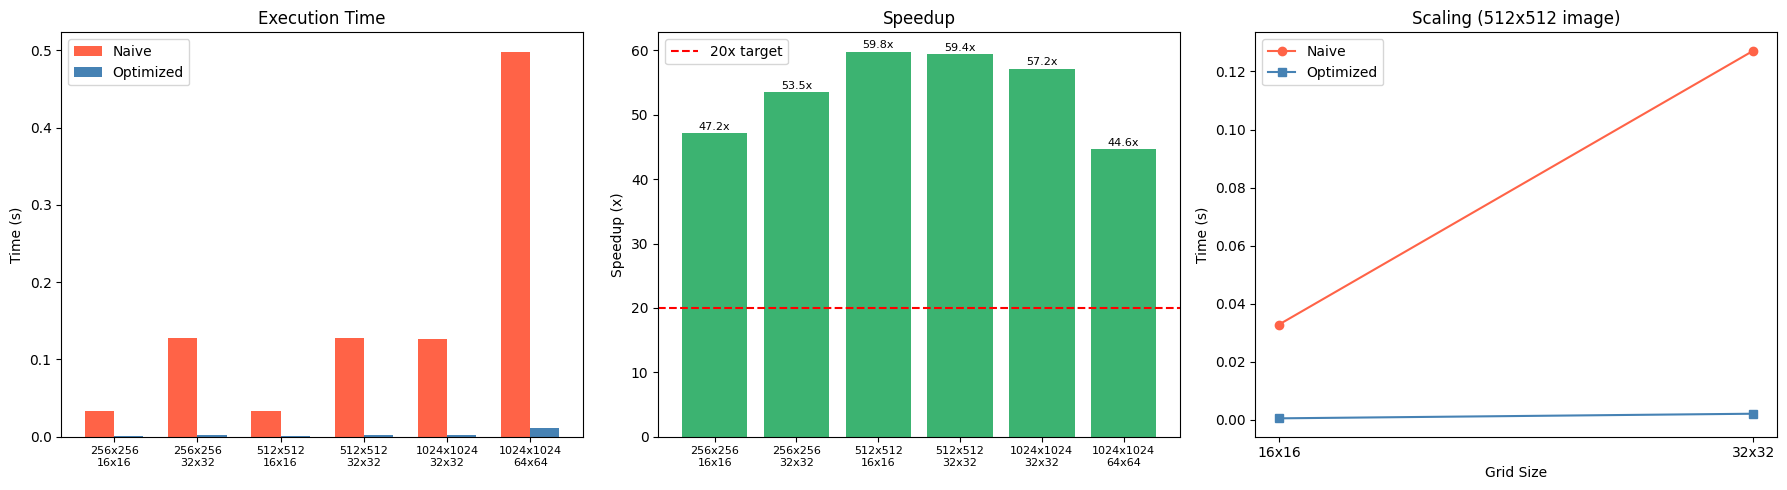

In [35]:
labels     = [f"{r[0]}\n{r[1]}x{r[1]}" for r in comparison]
naive_vals = [r[2] for r in comparison]
opt_vals   = [r[3] for r in comparison]
speedups   = [r[4] for r in comparison]
x, w = np.arange(len(labels)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(x - w/2, naive_vals, w, label='Naive',     color='tomato')
axes[0].bar(x + w/2, opt_vals,   w, label='Optimized', color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('Time (s)'); axes[0].set_title('Execution Time'); axes[0].legend()

bars = axes[1].bar(x, speedups, color='mediumseagreen')
axes[1].axhline(y=20, color='red', linestyle='--', label='20x target')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel('Speedup (x)'); axes[1].set_title('Speedup'); axes[1].legend()
for bar, sp in zip(bars, speedups):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{sp:.1f}x', ha='center', fontsize=8)

r512 = [r for r in comparison if '512' in r[0]]
axes[2].plot([f"{r[1]}x{r[1]}" for r in r512], [r[2] for r in r512], 'o-', color='tomato',    label='Naive')
axes[2].plot([f"{r[1]}x{r[1]}" for r in r512], [r[3] for r in r512], 's-', color='steelblue', label='Optimized')
axes[2].set_xlabel('Grid Size'); axes[2].set_ylabel('Time (s)')
axes[2].set_title('Scaling (512x512 image)'); axes[2].legend()

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150)
plt.show()

## 10. Visual Quality Check

MSE  naive vs optimized: 54.8379
SSIM naive vs optimized: 0.9930
Small differences are expected — different averaging methods.


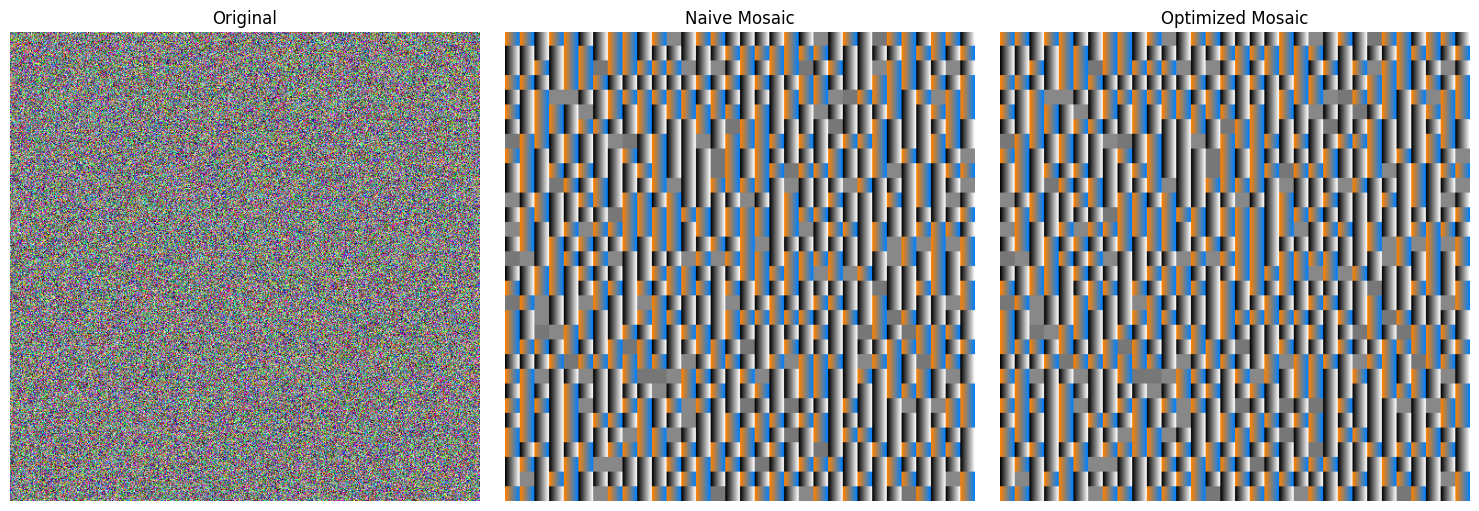

In [36]:
from mosaic_generator.metrics import compute_mse, compute_ssim

mosaic_naive = naive_generate_mosaic(img_512, grid_cells=32, tile_px=32)
mosaic_opt   = builder.create_mosaic(img_512)

print(f'MSE  naive vs optimized: {compute_mse(mosaic_naive, mosaic_opt):.4f}')
print(f'SSIM naive vs optimized: {compute_ssim(mosaic_naive, mosaic_opt):.4f}')
print('Small differences are expected — different averaging methods.')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_512);      axes[0].set_title('Original');         axes[0].axis('off')
axes[1].imshow(mosaic_naive); axes[1].set_title('Naive Mosaic');     axes[1].axis('off')
axes[2].imshow(mosaic_opt);   axes[2].set_title('Optimized Mosaic'); axes[2].axis('off')
plt.tight_layout(); plt.show()